In [26]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from typing import  TypedDict,List,Annotated
from operator import add
from langgraph.graph import StateGraph,START,END
from langchain_core.messages import  BaseMessage
from langchain_community.document_loaders import PyMuPDFLoader
import operator
from langchain_huggingface import  ChatHuggingFace,HuggingFaceEmbeddings,HuggingFaceEndpoint
from dotenv import load_dotenv
from langchain_ollama import ChatOllama
from langchain_community.tools import tool
from langchain_community.retrievers import WikipediaRetriever
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.prebuilt import ToolNode,tools_condition
from tavily import TavilyClient
from pydantic import BaseModel,Field
import os
from pymongo import MongoClient
from langchain_core.messages import BaseMessage
import operator




In [2]:
load_dotenv()

True

In [22]:
client = MongoClient("mongodb://localhost:27017/")
db = client['rag_memory']
collections = db["chat_history"]

In [23]:
collections.insert_one({
    "user_id": "user_1",
    "message": "Hello",
    "role": "user"
})

InsertOneResult(ObjectId('69ce284bb12114d4d3f24392'), acknowledged=True)

In [34]:
def save_to_memory(user_id, question, answer):
    collections.insert_one({
        "user_id": user_id,
        "question": question,
        "answer": answer
    })

In [ ]:
def get_memory(user_id):
    docs = collections.find({"user_id":user_id}).sort("_id",-1).limit(5)
    memory = ""
    for d in docs:
        memory +=f"User:{d['question']}\nAssitant:{d['answer']}\n"
    return memory

In [3]:
def load_multiple_pdfs(folder_path):
    all_docs = []

    for file in os.listdir(folder_path):
        if file.endswith(".pdf"):
            loader = PyMuPDFLoader(os.path.join(folder_path, file))
            docs = loader.load()

            # ✅ Add metadata (VERY IMPORTANT)
            for d in docs:
                d.metadata["source"] = file

            all_docs.extend(docs)

    return all_docs


In [5]:
docs = load_multiple_pdfs(r"C:\Users\Mayank Joshi\Downloads\pdfs")

In [6]:
splitter = RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=50)
chunks = splitter.split_documents(docs)

In [7]:
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2546.20it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
vector_store = FAISS.from_documents(
    documents=chunks,
    embedding=embeddings,
    
)



In [9]:
retriever = vector_store.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 4}
)

In [10]:
llm_ollama = ChatOllama(model="mistral:7b")
llm_hugging = HuggingFaceEndpoint(repo_id="meta-llama/Llama-3.1-8B-Instruct")
model = ChatHuggingFace(llm=llm_hugging)


In [27]:
class CRAGState(TypedDict):
    user_id:str
    question:str
    messages:Annotated[List[BaseMessage],operator.add]
    reterived_context:str
    filtered_context:str
    final_answer:str
    is_relevant:bool


In [43]:
def memory_node(state:CRAGState):
    user_id = state["user_id"]
    question = state["question"]
    past_memory = get_memory(user_id)
    return {
        "messages":[past_memory],
        "question":question,
    }


In [12]:
# Reterive Node for dicument Reterival

def Reterive_node(state:CRAGState):
    question = state['question']
    result = retriever.invoke(question)
    return {"reterived_context":result}

In [13]:
class Grade_Output(BaseModel):
    is_relevant:bool=Field(description="Are Documents relevant?")

In [14]:
def grade_documents(state:CRAGState):
    question = state["question"]
    context = state["reterived_context"]

    content = "\n".join([d.page_content for d in context])
    prompt = f"""
    Question:{question}
    Context:{context}
    Are these Document relevant for the given Question? Answer Only True or False
    """
    structured_llm = llm_ollama.with_structured_output(Grade_Output)
    result = structured_llm.invoke(prompt)

    return{"is_relevant":result.is_relevant}

In [15]:
def decide_path(state:CRAGState):
    if state["is_relevant"]:
        return "good"
    else:
        return "bad"

In [16]:
def rewrite_query(state:CRAGState):
    question = state["question"]
    docs= state["reterived_context"]
    context = "\n".join([d.page_content for d in docs])
    
    client = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))
    web_result = client.search(question)
    web_context = "\n".join([i["content"] for i in web_result["results"]])
    prompt = f"""
    You are a helpful assistant. Answer the user's question based on the provided context.

    Question: {question}

    Retrieved Documents:
    {context}

    Web Search Results:
    {web_context}

    Instructions:
    - Answer based on the context above
    - If documents and web results conflict, prefer the most recent web result
    - If the context doesn't contain the answer, say "I don't know"

    
    """
    result = model.invoke(prompt)
    return {"filtered_context":result.content}
    

In [40]:
def generate_answer(state: CRAGState):
    question = state["question"]

    context = state.get("filtered_context") or "\n".join(
        [d.page_content for d in state["reterived_context"]]
    )

    prompt = f"""
    Answer the question:

    Question: {question}
    Context: {context}
    """

    response = model.invoke(prompt)
    save_to_memory(state["user_id"],question,response.content)

    return {"final_answer": response.content}

In [30]:
builder = StateGraph(CRAGState)

builder.add_node("memory",memory_node)
builder.add_node("retrieve", Reterive_node)
builder.add_node("grade", grade_documents)
builder.add_node("rewrite", rewrite_query)
builder.add_node("generate", generate_answer)

builder.set_entry_point("memory")

builder.add_edge("memory", "retrieve")
builder.add_edge("retrieve","grade")

builder.add_conditional_edges(
    "grade",
    decide_path,
    {
        "good": "generate",
        "bad": "rewrite"
    }
)

builder.add_edge("rewrite", "generate")

graph = builder.compile()


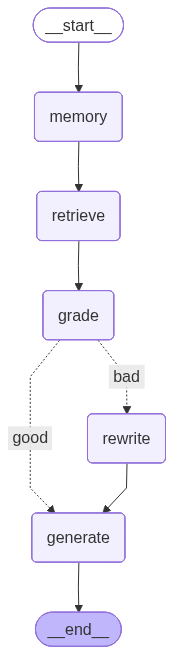

In [31]:
graph

In [44]:
result = graph.invoke({
    "user_id":"manku",
    "question":"What is the question i asked u earlier"
})

print(result["final_answer"])

Since I'm a large language model, I do not have the ability to retain any information about our previous conversation or recall any questions you may have asked earlier. Each time you interact with me, it's a new conversation, and I don't have any prior knowledge or memory of our previous chats.

So, in this case, I don't have a record of any previous question from you. Would you like to ask a new question, and I'll be happy to help?


In [1]:
import secrets

In [2]:
print(secrets.token_hex(32))

ce788a75212c338b526c8dbfb6dd5488904f6ead3b4d3385431489514a518e20
